In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout
from wandb_trainer import standard_trainer

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

loader_normalized = get_data(dataset_fn, dataset_config)

dataset_config["exclude"] = 'images'

loader_unnormalized = get_data(dataset_fn, dataset_config)

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
}

model_config["shifter"] = False
model_config["perspective"] = True

persp = stacked_core_full_gauss_readout(loader_unnormalized, random_seed, **model_config)

model_config["shifter"] = True
model_config["perspective"] = False

shift = stacked_core_full_gauss_readout(loader_normalized, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [ ]:
validation_score, trainer_output, state_dict = standard_trainer(
    persp, 
    loader_unnormalized, 
    random_seed, 
    max_iter=200, 
    verbose=False, 
    lr_decay_steps=4, 
    avg_loss=False, 
    lr_init=0.009, 
    track_training=False, 
    device=device,
    wandb_project='perspective'
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: nathan-soeding (nathan-soeding-uni-goettingen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 96: 100%|██████████| 35/35 [00:03<00:00,  9.78it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▂▃▃▅▆▇▇▇▇▇▇▇█▇█████████████████████████
val/poisson_loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.35439
final/validation_corr_mean,0.35439
val/correlation,0.3534
val/poisson_loss,2186972.0


message_loop has been closed
Traceback (most recent call last):
  File "/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/wandb/sdk/interface/router_sock.py", line 27, in _read_message
    return self._sock_client.read_server_response(timeout=1)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/wandb/sdk/lib/sock_client.py", line 235, in read_server_response
    data = self._read_packet_bytes(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/wandb/sdk/lib/sock_client.py", line 220, in _read_packet_bytes
    raise SockClientClosedError
wandb.sdk.lib.sock_client.SockClientClosedError

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/wandb/sdk/interface/router.py", line 56, 

In [5]:
validation_score, trainer_output, state_dict = standard_trainer(
    shift, 
    loader_normalized, 
    random_seed, 
    max_iter=200, 
    verbose=False, 
    lr_decay_steps=4, 
    avg_loss=False, 
    lr_init=0.009, 
    track_training=False, 
    device=device,
    wandb_project='perspective'
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 82: 100%|██████████| 35/35 [00:03<00:00, 11.20it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▂▂▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
val/poisson_loss,█▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.35213
final/validation_corr_mean,0.35213
val/correlation,0.34988
val/poisson_loss,2199263.5


In [6]:
persp.eval();
shift.eval();

In [135]:
data_key = '23343-5-17'
batches = list(iter(loader_unnormalized['train'][data_key]))

pupil_center = [batch[2] for batch in batches]

pupil_center = torch.cat(pupil_center)

In [136]:
rays = persp.perspective[data_key].retina.rays(pupil_center)
center_rays = rays[:, 17:19, 26:28, :]
proj = persp.perspective[data_key].monitor.project(center_rays)
points = proj.reshape(-1, 4, 2).cpu().detach().numpy()
persp_center = points.mean(axis=1)
persp_center = (persp_center - persp_center.mean(axis=0)) / persp_center.std(axis=0)

In [137]:
shift_center = shift.shifter[data_key](pupil_center).cpu().detach().numpy()
shift_center = (shift_center - shift_center.mean(axis=0)) / shift_center.std(axis=0)

In [138]:
dists = np.linalg.norm(persp_center - shift_center, axis=1)

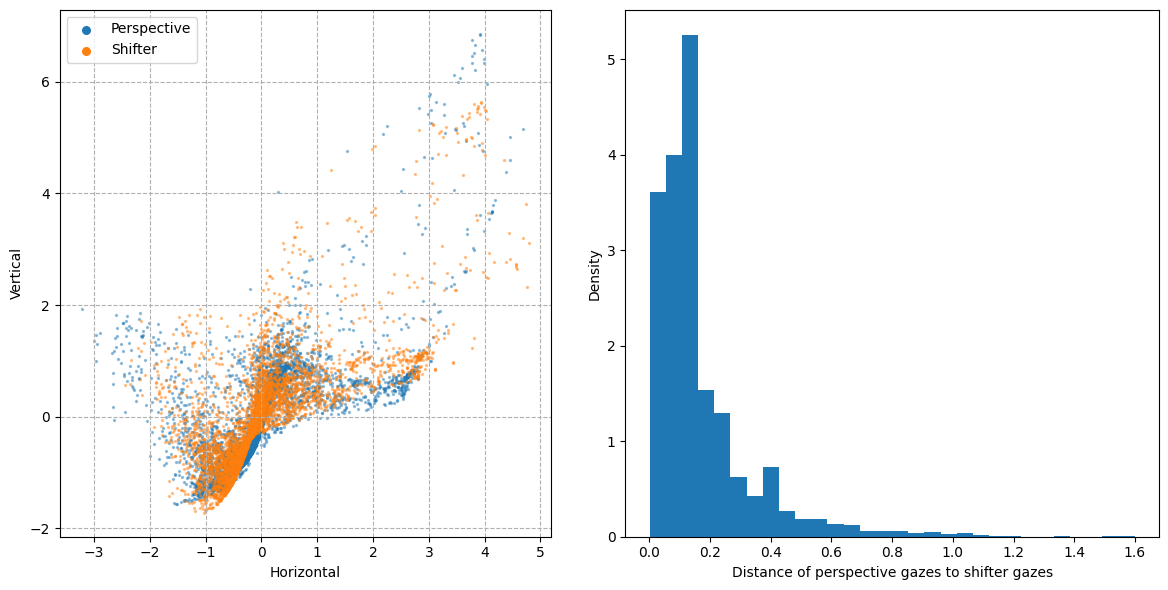

In [139]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].scatter(persp_center[:, 0], persp_center[:, 1], s=2, alpha=0.4, label='Perspective')
ax[0].scatter(shift_center[:, 0], shift_center[:, 1], s=2, alpha=0.4, label='Shifter')
ax[0].grid(linestyle='--')
#ax[0].set_ylim(-2, 7)
ax[0].set_aspect('equal')
ax[0].set_xlabel('Horizontal')
ax[0].set_ylabel('Vertical')

leg = ax[0].legend()
# Set larger marker size + alpha=1 for legend
for handle in leg.legend_handles:
    handle.set_sizes([30])  # Larger size
    handle.set_alpha(1)     # Fully opaque

ax[1].hist(dists, bins=30, density=True)
ax[1].set_xlabel('Distance of perspective gazes to shifter gazes')
ax[1].set_ylabel('Density')
plt.tight_layout()
plt.savefig('plots/gaze_comparison')
plt.show()

In [140]:
img = [batch[0] for batch in batches]

img = torch.cat(img)

tensor(0, device='cuda:7')
img shape: torch.Size([4466, 1, 36, 64])
perspective output shape: torch.Size([10, 36, 54])


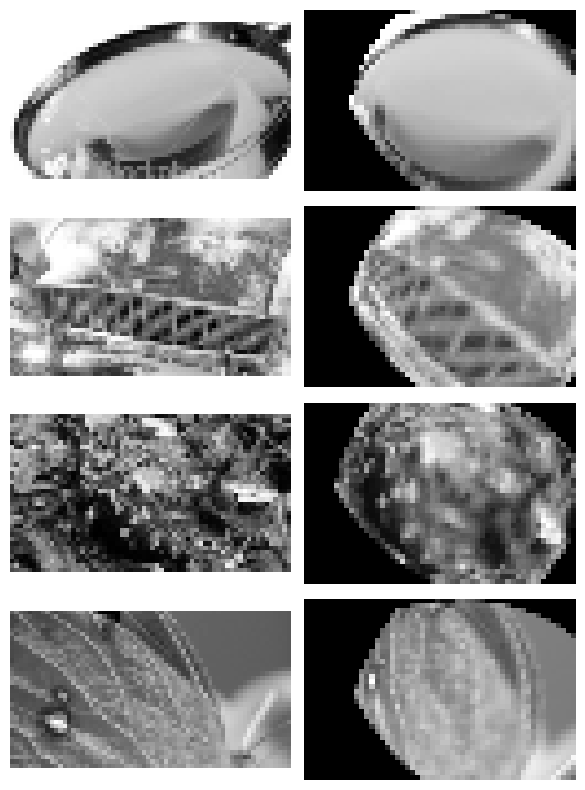

In [154]:
fig, ax = plt.subplots(4, 2, figsize=(6, 8))

out = persp.perspective[data_key](img[:10], pupil_center[:10])
print(out.isnan().sum())
out = out[:, 0].detach().cpu()

print("img shape:", img.shape)
print("perspective output shape:", out.shape)

for i in range(4):
    ax[i, 0].imshow(img.cpu()[i, 0], cmap="gray")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(out[i], cmap="gray")
    ax[i, 1].axis("off")

plt.tight_layout()
plt.savefig('plots/perspective_outputs', pad_inches=0)
plt.show()